Device: cuda
Dataset shape: (166009, 7)
                                             Reviews  MedicineFor  IntakeTime  \
0  actually i use the generic brand of the hour n...         1749        4400   
1  cap took minutes to open process was frustrati...         1749        4406   
2  hi everyone htpfor anxietyoctgannutaken for le...         1274        4406   
3  took ssri prozac for anxietydepression for yea...         1274        4399   
4  i have been suffering from severe panic disord...         1274        4406   

   ReviewLength  NumberOfLikes  Rating  label  
0     -0.104701      -0.545990      10      1  
1      0.101196      -0.545990       1      0  
2      1.054425       6.736677      10      1  
3     -0.726206       4.288012       9      1  
4      1.363271       4.034702      10      1  
label
1    102489
0     63520
Name: count, dtype: int64
Train shape: (132807, 6)
Test shape: (33202, 6)
Vocab size: 40000
Loaded GloVe words: 400000
Train text shape: (132807, 220)
Trai

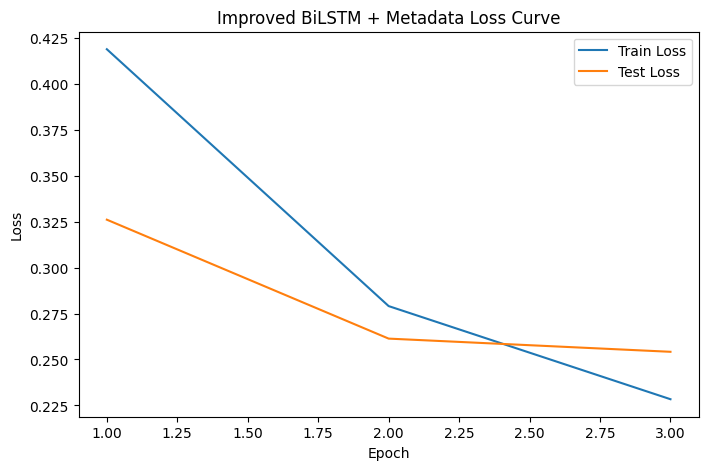

In [1]:
# =========================================================
# Improved Hybrid BiLSTM + Metadata Embeddings
# =========================================================

import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from collections import Counter
import matplotlib.pyplot as plt
import re

# -------------------------
# 1. Reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------------
# 2. Load dataset
# -------------------------
FILE_PATH = "binary_extreme.csv"   # change this only
df = pd.read_csv(FILE_PATH)

print("Dataset shape:", df.shape)
print(df.head())
print(df["label"].value_counts())

# -------------------------
# 3. Keep required columns
# -------------------------
df = df[[
    "Reviews",
    "MedicineFor",
    "IntakeTime",
    "ReviewLength",
    "NumberOfLikes",
    "label"
]].copy()

df["Reviews"] = df["Reviews"].astype(str)

# -------------------------
# 4. Train-test split
# -------------------------
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# -------------------------
# 5. Build vocabulary from training text
# -------------------------


def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

counter = Counter()
for text in train_df["Reviews"]:
    counter.update(tokenize(text))

MAX_VOCAB_SIZE = 40000
special_tokens = ["<PAD>", "<UNK>"]

most_common = counter.most_common(MAX_VOCAB_SIZE - len(special_tokens))
vocab = {word: idx + len(special_tokens) for idx, (word, _) in enumerate(most_common)}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

print("Vocab size:", len(vocab))

# Load GloVe embeddings
glove_path = "glove.6B.300d.txt"   # change path if needed
embedding_index = {}

with open(glove_path, "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

print("Loaded GloVe words:", len(embedding_index))

# Create embedding matrix
EMBED_DIM = 300
embedding_matrix = np.zeros((len(vocab), EMBED_DIM))

for word, idx in vocab.items():
    if word in embedding_index:
        embedding_matrix[idx] = embedding_index[word]
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(EMBED_DIM,))

# -------------------------
# 6. Convert reviews to padded sequences
# -------------------------
MAX_LEN = 220

def text_to_sequence(text, vocab, max_len=150):
    tokens = tokenize(text)
    seq = [vocab.get(token, vocab["<UNK>"]) for token in tokens]

    if len(seq) < max_len:
        seq = seq + [vocab["<PAD>"]] * (max_len - len(seq))
    else:
        seq = seq[:max_len]

    return seq

train_sequences = np.array([text_to_sequence(text, vocab, MAX_LEN) for text in train_df["Reviews"]])
test_sequences  = np.array([text_to_sequence(text, vocab, MAX_LEN) for text in test_df["Reviews"]])

# -------------------------
# 7. Metadata preparation
#    IMPORTANT:
#    - MedicineFor and IntakeTime are categorical -> use embeddings
#    - ReviewLength and NumberOfLikes are numeric -> use dense layer
# -------------------------
X_train_meta = train_df[["ReviewLength", "NumberOfLikes"]].values.astype(np.float32)
X_test_meta  = test_df[["ReviewLength", "NumberOfLikes"]].values.astype(np.float32)

train_medicinefor = train_df["MedicineFor"].values.astype(np.int64)
test_medicinefor  = test_df["MedicineFor"].values.astype(np.int64)

train_intaketime = train_df["IntakeTime"].values.astype(np.int64)
test_intaketime  = test_df["IntakeTime"].values.astype(np.int64)

y_train = train_df["label"].values
y_test  = test_df["label"].values

print("Train text shape:", train_sequences.shape)
print("Train numeric meta shape:", X_train_meta.shape)

# -------------------------
# 8. Dataset class
# -------------------------
class HybridReviewDataset(Dataset):
    def __init__(self, text_sequences, meta_features, medicinefor, intaketime, labels):
        self.text_sequences = torch.tensor(text_sequences, dtype=torch.long)
        self.meta_features = torch.tensor(meta_features, dtype=torch.float32)
        self.medicinefor = torch.tensor(medicinefor, dtype=torch.long)
        self.intaketime = torch.tensor(intaketime, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.text_sequences[idx],
            self.meta_features[idx],
            self.medicinefor[idx],
            self.intaketime[idx],
            self.labels[idx]
        )

train_dataset = HybridReviewDataset(
    train_sequences,
    X_train_meta,
    train_medicinefor,
    train_intaketime,
    y_train
)

test_dataset = HybridReviewDataset(
    test_sequences,
    X_test_meta,
    test_medicinefor,
    test_intaketime,
    y_test
)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# -------------------------
# 9. Improved hybrid model
# -------------------------
class BiLSTMWithMetadata(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        output_dim,
        num_layers,
        dropout,
        medicinefor_vocab_size,
        intaketime_vocab_size,
        cat_embed_dim,
        numeric_input_dim,
        numeric_hidden_dim
    ):
        super(BiLSTMWithMetadata, self).__init__()

        # Text branch
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=False,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Categorical metadata embeddings
        self.medicinefor_embedding = nn.Embedding(medicinefor_vocab_size + 1, cat_embed_dim)
        self.intaketime_embedding = nn.Embedding(intaketime_vocab_size + 1, cat_embed_dim)

        # Numeric metadata branch
        self.numeric_fc = nn.Sequential(
            nn.Linear(numeric_input_dim, numeric_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Final fusion
        fusion_dim = hidden_dim * 2 + cat_embed_dim + cat_embed_dim + numeric_hidden_dim
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(fusion_dim, output_dim)

    def forward(self, text, meta_numeric, medicinefor, intaketime):
        # Text branch
        embedded = self.embedding(text)
        lstm_out, (hidden, cell) = self.lstm(embedded)

        forward_hidden = hidden[-2, :, :]
        backward_hidden = hidden[-1, :, :]
        text_features = torch.cat((forward_hidden, backward_hidden), dim=1)

        # Categorical branches
        medicinefor_features = self.medicinefor_embedding(medicinefor)
        intaketime_features = self.intaketime_embedding(intaketime)

        # Numeric branch
        numeric_features = self.numeric_fc(meta_numeric)

        # Combine
        combined = torch.cat(
            (text_features, medicinefor_features, intaketime_features, numeric_features),
            dim=1
        )
        combined = self.dropout(combined)

        out = self.fc(combined)
        return out

VOCAB_SIZE = len(vocab)
EMBED_DIM = 300
HIDDEN_DIM = 512
OUTPUT_DIM = 2
NUM_LAYERS = 2
DROPOUT = 0.55

MEDICINEFOR_VOCAB_SIZE = int(df["MedicineFor"].max())
INTAKETIME_VOCAB_SIZE = int(df["IntakeTime"].max())

CAT_EMBED_DIM = 32
NUMERIC_INPUT_DIM = 2
NUMERIC_HIDDEN_DIM = 32

model = BiLSTMWithMetadata(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    medicinefor_vocab_size=MEDICINEFOR_VOCAB_SIZE,
    intaketime_vocab_size=INTAKETIME_VOCAB_SIZE,
    cat_embed_dim=CAT_EMBED_DIM,
    numeric_input_dim=NUMERIC_INPUT_DIM,
    numeric_hidden_dim=NUMERIC_HIDDEN_DIM
).to(device)

print(model)

# -------------------------
# 10. Loss and optimizer
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

# -------------------------
# 11. Training loop
# -------------------------
EPOCHS = 3

train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0

    for text_batch, meta_batch, medicinefor_batch, intaketime_batch, labels in train_loader:
        text_batch = text_batch.to(device)
        meta_batch = meta_batch.to(device)
        medicinefor_batch = medicinefor_batch.to(device)
        intaketime_batch = intaketime_batch.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(text_batch, meta_batch, medicinefor_batch, intaketime_batch)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_test_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for text_batch, meta_batch, medicinefor_batch, intaketime_batch, labels in test_loader:
            text_batch = text_batch.to(device)
            meta_batch = meta_batch.to(device)
            medicinefor_batch = medicinefor_batch.to(device)
            intaketime_batch = intaketime_batch.to(device)
            labels = labels.to(device)

            outputs = model(text_batch, meta_batch, medicinefor_batch, intaketime_batch)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_test_loss = running_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    acc = accuracy_score(all_labels, all_preds)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Test Loss : {avg_test_loss:.4f}")
    print(f"Accuracy  : {acc:.4f}")
    print("-" * 40)

# -------------------------
# 12. Final evaluation
# -------------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for text_batch, meta_batch, medicinefor_batch, intaketime_batch, labels in test_loader:
        text_batch = text_batch.to(device)
        meta_batch = meta_batch.to(device)
        medicinefor_batch = medicinefor_batch.to(device)
        intaketime_batch = intaketime_batch.to(device)
        labels = labels.to(device)

        outputs = model(text_batch, meta_batch, medicinefor_batch, intaketime_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0
)

print("\nFinal Improved Hybrid BiLSTM Results")
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1       :", f1)

print("\nClassification Report")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["negative", "positive"],
    zero_division=0
))

# -------------------------
# 13. Plot loss curves
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved BiLSTM + Metadata Loss Curve")
plt.legend()
plt.show()